# Investigating the distribution of temperature brightnesses (TB) within the TC-PRIMED PMW observations.

## Imports and setup

In [1]:
%cd ../../..
%matplotlib widget
%load_ext autoreload
%autoreload 2

/home/cdauvill/inria/multi_sources


In [35]:
import xarray as xr
from xarray.backends import NetCDF4DataStore
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from hydra import compose, initialize
from netCDF4 import Dataset
from pathlib import Path
from global_land_mask import globe
from preproc.utils import list_tc_primed_overpass_files_by_sensat

In [8]:
# context initialization
with initialize(version_base=None, config_path="../../../configs"):
    cfg = compose(config_name="preproc", overrides=["paths=local"])

tc_primed_path = Path(cfg["paths"]["raw_datasets"]) / "tc_primed"

In [ ]:
# Dict of instrument -> {swath_containing_37GHz: [list_of_variables],
#                             swath_containing_89GHz: [list_of_variables], ...}
# or {swath: [list_of_variables]} if a single swath contains both 37GHz and 89GHz.
# Written from the TC-PRIMED documentation.
SENSOR_VARIABLES = {
    "AMSR2": {"37": ("S4", ["36.5H", "36.5V"]), "89": ("S5", ["A89.0H", "A89.0V"])},
    "AMSRE": {"37": ("S4", ["36.5H", "36.5V"]), "89": ("S5", ["A89.0H", "A89.0V"])},
    "GMI": {"37": ("S1", ["36.64H", "36.64V"]), "89": ("S1", ["89.0H", "89.0V"])},
    "SSMI": {"37": ("S1", ["37.0H", "37.0V"]), "89": ("S2", ["85.5H", "85.5V"])},
    "SSMIS": {"37": ("S2", ["37.0H", "37.0V"]), "89": ("S4", ["91.665H", "91.665V"])},
    "TMI": {"37": ("S2", ["37.0H", "37.0V"]), "89": ("S3", ["85.5H", "85.5V"])},
}
# Add the "TB" prefix to all variable names
for sensor in SENSOR_VARIABLES:
    for freq in SENSOR_VARIABLES[sensor]:
        swath, vars = SENSOR_VARIABLES[sensor][freq]
        SENSOR_VARIABLES[sensor][freq] = (swath, [f"TB_{var}" for var in vars])

## Computing the distribution of TB within each channel

In [11]:
# Retrieve all TC-PRIMED overpass files as a dict {sen_sat: <file_list>}
pmw_files = list_tc_primed_overpass_files_by_sensat(tc_primed_path)
print(f"Found {len(pmw_files)} PMW sources: {list(pmw_files.keys())}")

# Only keep those that are in SENSOR_VARIABLES
pmw_files = {k: v for k, v in pmw_files.items() if any(s in k for s in SENSOR_VARIABLES)}
print(f"Keeping {len(pmw_files)} PMW sources: {list(pmw_files.keys())}")

Found 12 PMW sources: ['SSMIS_F19', 'SSMIS_F18', 'MHS_METOPB', 'ATMS_NPP', 'GMI_GPM', 'SSMIS_F16', 'MHS_METOPA', 'AMSR2_GCOMW1', 'MHS_NOAA19', 'MHS_NOAA18', 'SSMIS_F17', 'TMI_TRMM']
Keeping 7 PMW sources: ['SSMIS_F19', 'SSMIS_F18', 'GMI_GPM', 'SSMIS_F16', 'AMSR2_GCOMW1', 'SSMIS_F17', 'TMI_TRMM']


In [31]:
# Now we'll retrieve the TB values for each channel from all sources.
tb_37H, tb_37V, tb_89H, tb_89V = [], [], [], []
for sensat in pmw_files:
    print(f"Processing {sensat}...")
    for file in tqdm(pmw_files[sensat]):
        with Dataset(file) as ds:
            ds = ds['passive_microwave']
            sensor = sensat.split("_")[0]  # e.g. "AMSR2" from "AMSR2_GCOMW1"
            swath_37, (var_37H, var_37V) = SENSOR_VARIABLES[sensor]["37"]
            swath_89, (var_89H, var_89V) = SENSOR_VARIABLES[sensor]["89"]
            ds_37 = xr.open_dataset(NetCDF4DataStore(ds[swath_37]), decode_times=False)
            ds_89 = xr.open_dataset(NetCDF4DataStore(ds[swath_89]), decode_times=False)
            data_37H = ds_37[var_37H].values.flatten()
            data_37V = ds_37[var_37V].values.flatten()
            data_89H = ds_89[var_89H].values.flatten()
            data_89V = ds_89[var_89V].values.flatten()
            # Remove NaNs
            data_37H = data_37H[~np.isnan(data_37H)]
            data_37V = data_37V[~np.isnan(data_37V)]
            data_89H = data_89H[~np.isnan(data_89H)]
            data_89V = data_89V[~np.isnan(data_89V)]
            # Append to lists
            tb_37H.append(data_37H)
            tb_37V.append(data_37V)
            tb_89H.append(data_89H)
            tb_89V.append(data_89V)
# Concatenate all arrays
tb_37H = np.concatenate(tb_37H)
tb_37V = np.concatenate(tb_37V)
tb_89H = np.concatenate(tb_89H)
tb_89V = np.concatenate(tb_89V)
print(f"Total samples collected: 37H={len(tb_37H)}, 37V={len(tb_37V)}, 89H={len(tb_89H)}, 89V={len(tb_89V)}")

Processing SSMIS_F19...


100%|██████████| 119/119 [00:01<00:00, 69.60it/s]


Processing SSMIS_F18...


100%|██████████| 355/355 [00:05<00:00, 69.75it/s]


Processing GMI_GPM...


...

Processing SSMIS_F17...


100%|██████████| 356/356 [00:05<00:00, 64.77it/s]


Processing TMI_TRMM...


100%|██████████| 266/266 [00:04<00:00, 62.11it/s]


Total samples collected: 37H=45223114, 37V=45223114, 89H=83267028, 89V=83273751


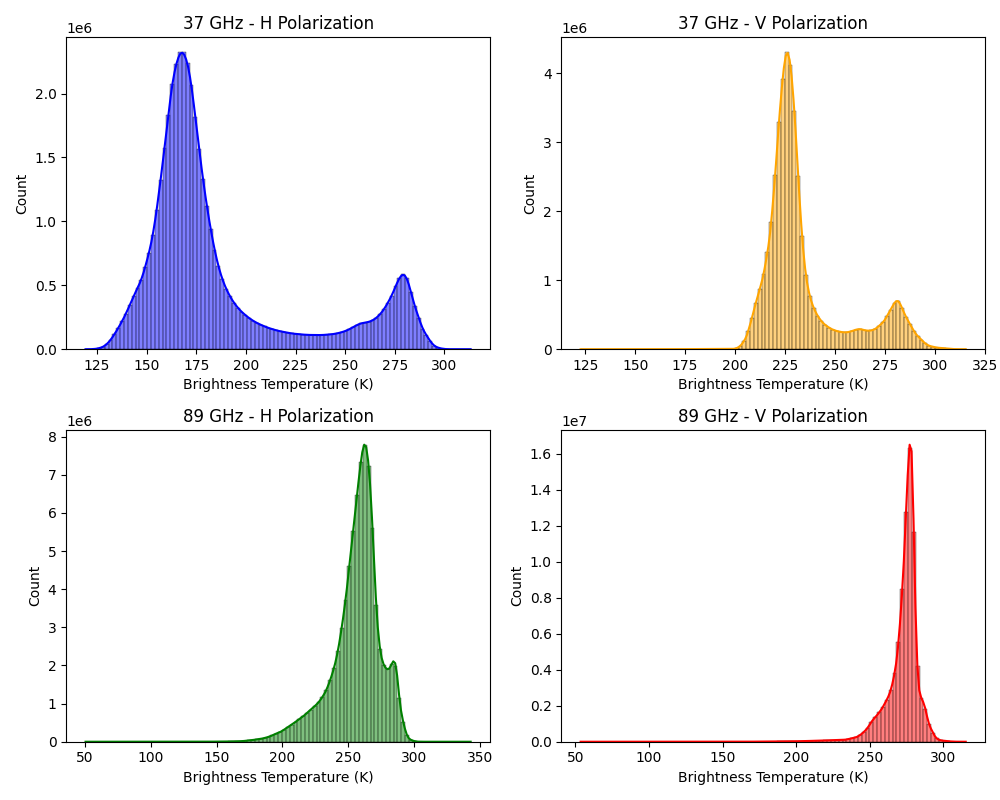

In [32]:
# We'll now plot the distributions as a 2,2 grid
# Top row is 37GHz, bottom row is 89GHz
# Left column is H pol, right column is V pol
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
sns.histplot(tb_37H, bins=100, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('37 GHz - H Polarization')
axes[0, 0].set_xlabel('Brightness Temperature (K)')
sns.histplot(tb_37V, bins=100, kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('37 GHz - V Polarization')
axes[0, 1].set_xlabel('Brightness Temperature (K)')
sns.histplot(tb_89H, bins=100, kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('89 GHz - H Polarization')
axes[1, 0].set_xlabel('Brightness Temperature (K)')
sns.histplot(tb_89V, bins=100, kde=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title('89 GHz - V Polarization')
axes[1, 1].set_xlabel('Brightness Temperature (K)')
plt.tight_layout()
plt.show()

One can clearly distinguish two modes, with the brighter one (between 275 and 300K) corresponding to land pixels. The 37GHz channels are particularly affected, while the effect on the 89V channel is rather limited.

Let's try to ignore land pixels to see the distribution without them.

In [37]:
# Same code, but ignores land pixels using the global_land_mask package.
tb_37H, tb_37V, tb_89H, tb_89V = [], [], [], []
for sensat in pmw_files:
    print(f"Processing {sensat}...")
    for file in tqdm(pmw_files[sensat]):
        with Dataset(file) as ds:
            ds = ds['passive_microwave']
            sensor = sensat.split("_")[0]  # e.g. "AMSR2" from "AMSR2_GCOMW1"
            swath_37, (var_37H, var_37V) = SENSOR_VARIABLES[sensor]["37"]
            swath_89, (var_89H, var_89V) = SENSOR_VARIABLES[sensor]["89"]
            ds_37 = xr.open_dataset(NetCDF4DataStore(ds[swath_37]), decode_times=False)
            ds_89 = xr.open_dataset(NetCDF4DataStore(ds[swath_89]), decode_times=False)
            # Retrieve the values
            data_37H = ds_37[var_37H].values
            data_37V = ds_37[var_37V].values
            data_89H = ds_89[var_89H].values
            data_89V = ds_89[var_89V].values
            # Retrieve the lat/lon values and convert the longitudes to [-180, 180]
            lats_37 = ds_37['latitude'].values
            lons_37 = ds_37['longitude'].values
            lons_37 = (lons_37 + 180) % 360 - 180
            lats_89 = ds_89['latitude'].values
            lons_89 = ds_89['longitude'].values
            lons_89 = (lons_89 + 180) % 360 - 180
            # Set land pixels to NaN
            land_mask_37 = globe.is_land(lats_37, lons_37)
            land_mask_89 = globe.is_land(lats_89, lons_89)
            data_37H[land_mask_37] = np.nan
            data_37V[land_mask_37] = np.nan
            data_89H[land_mask_89] = np.nan
            data_89V[land_mask_89] = np.nan
            # Remove NaNs and flatten
            data_37H = data_37H[~np.isnan(data_37H)]
            data_37V = data_37V[~np.isnan(data_37V)]
            data_89H = data_89H[~np.isnan(data_89H)]
            data_89V = data_89V[~np.isnan(data_89V)]
            # Append to lists
            tb_37H.append(data_37H)
            tb_37V.append(data_37V)
            tb_89H.append(data_89H)
            tb_89V.append(data_89V)
# Concatenate all arrays
tb_37H = np.concatenate(tb_37H)
tb_37V = np.concatenate(tb_37V)
tb_89H = np.concatenate(tb_89H)
tb_89V = np.concatenate(tb_89V)
print(f"Total samples collected: 37H={len(tb_37H)}, 37V={len(tb_37V)}, 89H={len(tb_89H)}, 89V={len(tb_89V)}")

Processing SSMIS_F19...


100%|██████████| 119/119 [00:02<00:00, 56.69it/s]


Processing SSMIS_F18...


100%|██████████| 355/355 [00:06<00:00, 57.48it/s]


Processing GMI_GPM...


...

Processing SSMIS_F17...


100%|██████████| 356/356 [00:06<00:00, 56.69it/s]


Processing TMI_TRMM...


100%|██████████| 266/266 [00:05<00:00, 51.81it/s]


Total samples collected: 37H=38354549, 37V=38354549, 89H=70869423, 89V=70876124


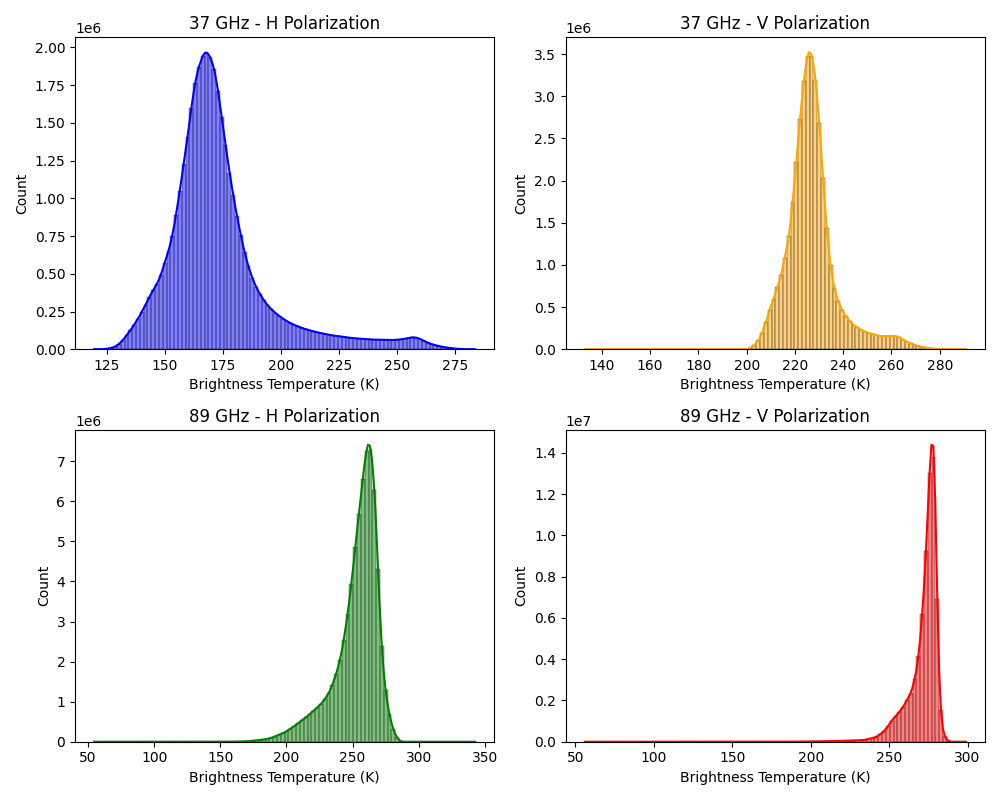

In [38]:
# Same plot as before but without land pixels
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
sns.histplot(tb_37H, bins=100, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('37 GHz - H Polarization')
axes[0, 0].set_xlabel('Brightness Temperature (K)')
sns.histplot(tb_37V, bins=100, kde=True, ax=axes[0, 1], color='orange')
axes[0, 1].set_title('37 GHz - V Polarization')
axes[0, 1].set_xlabel('Brightness Temperature (K)')
sns.histplot(tb_89H, bins=100, kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('89 GHz - H Polarization')
axes[1, 0].set_xlabel('Brightness Temperature (K)')
sns.histplot(tb_89V, bins=100, kde=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title('89 GHz - V Polarization')
axes[1, 1].set_xlabel('Brightness Temperature (K)')
plt.tight_layout()
plt.show()